<a href="https://colab.research.google.com/github/rakshiiiita/Object-Detection-model-Cat-Dog-/blob/main/Experiment08(actual).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Experiment** - 8

**Name: Rakshita Dhaketa**

**EN23ME304083**

*Aim: Object Detection and Recognition on available online image dataset.*

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving animal dataset.zip to animal dataset.zip


In [ ]:
import zipfile
import os

zip_path = "/content/animal dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall("/content/data")
print("Unzipped!")

Unzipped!


In [ ]:
os.listdir("/content/data")

['test', 'train']

In [ ]:
#IMPORT DATASET (Splitted data)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#iMAGE SIZE
IMG_SIZE = 150
BATCH_SIZE = 32

#Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory('/content/data/train', target_size=(IMG_SIZE, IMG_SIZE),
                                                  batch_size=BATCH_SIZE, class_mode='binary')
test_data = test_datagen.flow_from_directory('/content/data/test', target_size=(IMG_SIZE, IMG_SIZE),
                                                batch_size=BATCH_SIZE, class_mode='binary')

Found 557 images belonging to 2 classes.
Found 140 images belonging to 2 classes.


In [ ]:
model = tf. keras.models.Sequential([tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation='relu'),
                                    tf.keras.layers.Dense(1, activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,636,481 (40.57 MB)

 Trainable params: 10,636,481 (40.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10
history = model.fit(train_data, validation_data = test_data, epochs=EPOCHS)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 877ms/step - accuracy: 0.5045 - loss: 1.6499 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 891ms/step - accuracy: 0.5745 - loss: 0.6889 - val_accuracy: 0.5571 - val_loss: 0.6893
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 880ms/step - accuracy: 0.5853 - loss: 0.6754 - val_accuracy: 0.6000 - val_loss: 0.6735
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 862ms/step - accuracy: 0.6391 - loss: 0.6316 - val_accuracy: 0.6571 - val_loss: 0.6626
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 893ms/step - accuracy: 0.7666 - loss: 0.5234 - val_accuracy: 0.5857 - val_loss: 0.6632
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 877ms/step - accuracy: 0.8420 - loss: 0.3802 - val_accuracy: 0.6143 - val_loss: 0.7062
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 860ms/step - accuracy: 0.9228 - loss: 0.2434 - val_accuracy: 0.6000 - val_loss: 0.7699
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 895ms/step - accuracy: 0.9641 - loss: 0.1527 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


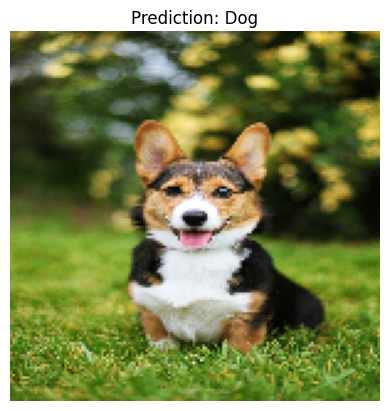

Model Prediction: Dog


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = '/content/DOG.jpg'
img = image.load_img(img_path, target_size=(150,150))

plt.imshow(img)
plt.axis('off')

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
  label = "Dog"
else:
  label = "Cat"

plt.title(f"Prediction: {label}")
plt.show()

print("Model Prediction:", label)